# 🔍 Insider Threat Dataset — Exploratory Data Analysis

**Dataset:** `insider_threat_clean_dataset.csv`  
**Records:** 118,614 | **Features:** 22 | **Target:** `is_malicious`  

---
### Sections
1. Setup & Load
2. Basic EDA — Shape, Types, Missing Values
3. Target Distribution & Class Imbalance
4. Univariate Analysis — Numerical Features
5. Univariate Analysis — Categorical Features
6. Correlation Analysis
7. User Behaviour & Anomaly Indicators
8. Time-Related / Session Analysis
9. Feature Importance (Quick RF Proxy)
10. Summary & Key Findings

---
## 1. Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
MALICIOUS_COLOR   = '#e74c3c'
BENIGN_COLOR      = '#2ecc71'
ACCENT_COLOR      = '#3498db'
PALETTE           = [BENIGN_COLOR, MALICIOUS_COLOR]

# ── Load ───────────────────────────────────────────────
DATA_PATH =DATA_PATH = '/Users/wadalisam/Documents/GitHub/insider-threat-detector/data/raw/insider_threat_clean_dataset.csv'   # adjust if needed
df = pd.read_csv(DATA_PATH)

print(f'Shape : {df.shape}')
df.head()

Shape : (118614, 22)


,employee_department,employee_campus,employee_position,employee_seniority_years,is_contractor,employee_classification,has_foreign_citizenship,has_criminal_record,has_medical_history,employee_origin_country,...,total_files_burned,burned_from_other,is_abroad,trip_day_number,hostility_country_level,num_entries,num_unique_campus,late_exit_flag,entry_during_weekend,is_malicious
0,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,4,0,0,0.0,0,1,1,0,1,0
1,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,0,0,0.0,0,1,1,0,0,0
2,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,2,0,0,0.0,0,1,1,0,0,0
3,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,0,0,0.0,0,1,1,0,0,0
4,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,0,0,0.0,0,0,0,0,0,0


---
## 2. Basic EDA — Shape, Types, Missing Values

In [2]:
# Column types
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c != 'is_malicious']   # exclude target

print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')
print(f'Numerical  columns ({len(num_cols)}): {num_cols}')

Categorical columns (4): ['employee_department', 'employee_campus', 'employee_position', 'employee_origin_country']
Numerical  columns (17): ['employee_seniority_years', 'is_contractor', 'employee_classification', 'has_foreign_citizenship', 'has_criminal_record', 'has_medical_history', 'total_printed_pages', 'num_printed_pages_off_hours', 'total_files_burned', 'burned_from_other', 'is_abroad', 'trip_day_number', 'hostility_country_level', 'num_entries', 'num_unique_campus', 'late_exit_flag', 'entry_during_weekend']


In [3]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_%', ascending=False)

if missing_df.empty:
    print('✅ No missing values found.')
else:
    display(missing_df)
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df['missing_%'].plot(kind='bar', ax=ax, color=ACCENT_COLOR)
    ax.set_title('Missing Value Percentage by Column')
    ax.set_ylabel('% Missing')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

✅ No missing values found.


In [4]:
# Descriptive statistics
df[num_cols].describe().T.style.background_gradient(cmap='Blues', axis=1)

,count,mean,std,min,25%,50%,75%,max
employee_seniority_years,118614.000000,12.371508,7.195372,0.000000,7.000000,12.000000,18.000000,31.000000
is_contractor,118614.000000,0.140616,0.347626,0.000000,0.000000,0.000000,0.000000,1.000000
employee_classification,118614.000000,1.889743,0.749889,1.000000,1.000000,2.000000,2.000000,4.000000
has_foreign_citizenship,118614.000000,0.163168,0.369520,0.000000,0.000000,0.000000,0.000000,1.000000
has_criminal_record,118614.000000,0.049311,0.216518,0.000000,0.000000,0.000000,0.000000,1.000000
has_medical_history,118614.000000,0.151340,0.358381,0.000000,0.000000,0.000000,0.000000,1.000000
total_printed_pages,118614.000000,13.708458,25.071183,0.000000,0.000000,5.000000,18.000000,728.000000
num_printed_pages_off_hours,118614.000000,0.583894,4.293502,0.000000,0.000000,0.000000,0.000000,253.000000
total_files_burned,118614.000000,9.380815,19.724109,0.000000,0.000000,0.000000,7.000000,186.000000
burned_from_other,118614.000000,0.007234,0.084742,0.000000,0.000000,0.000000,0.000000,1.000000


---
## 3. Target Distribution & Class Imbalance

Class Distribution:
               count      %
is_malicious               
0             112228  94.62
1               6386   5.38


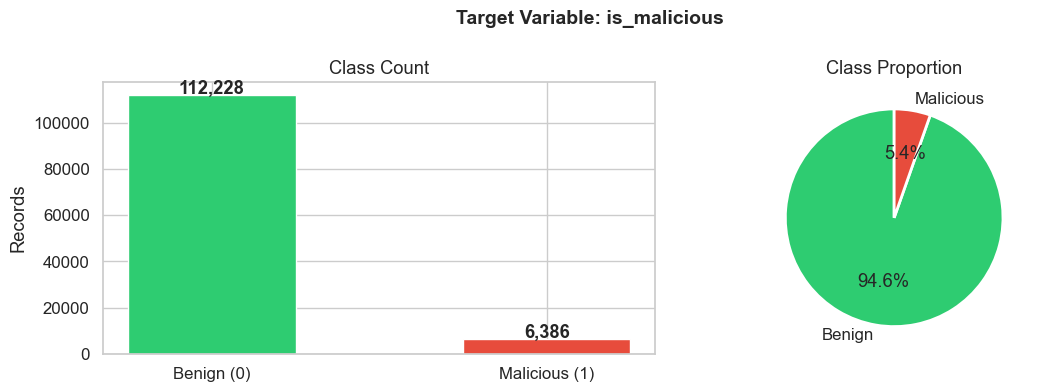


⚠️  Imbalance ratio (benign:malicious) = 17.6:1
   Consider SMOTE, class_weight="balanced", or stratified sampling for modelling.


In [5]:
target_counts = df['is_malicious'].value_counts()
target_pct    = df['is_malicious'].value_counts(normalize=True) * 100

print('Class Distribution:')
print(pd.DataFrame({'count': target_counts, '%': target_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar
axes[0].bar(['Benign (0)', 'Malicious (1)'], target_counts.values, color=PALETTE, edgecolor='white', width=0.5)
axes[0].set_title('Class Count')
axes[0].set_ylabel('Records')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie
axes[1].pie(target_counts.values, labels=['Benign', 'Malicious'],
            autopct='%1.1f%%', colors=PALETTE, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion')

plt.suptitle('Target Variable: is_malicious', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

imbalance_ratio = target_counts[0] / target_counts[1]
print(f'\n⚠️  Imbalance ratio (benign:malicious) = {imbalance_ratio:.1f}:1')
print('   Consider SMOTE, class_weight="balanced", or stratified sampling for modelling.')

---
## 4. Univariate Analysis — Numerical Features

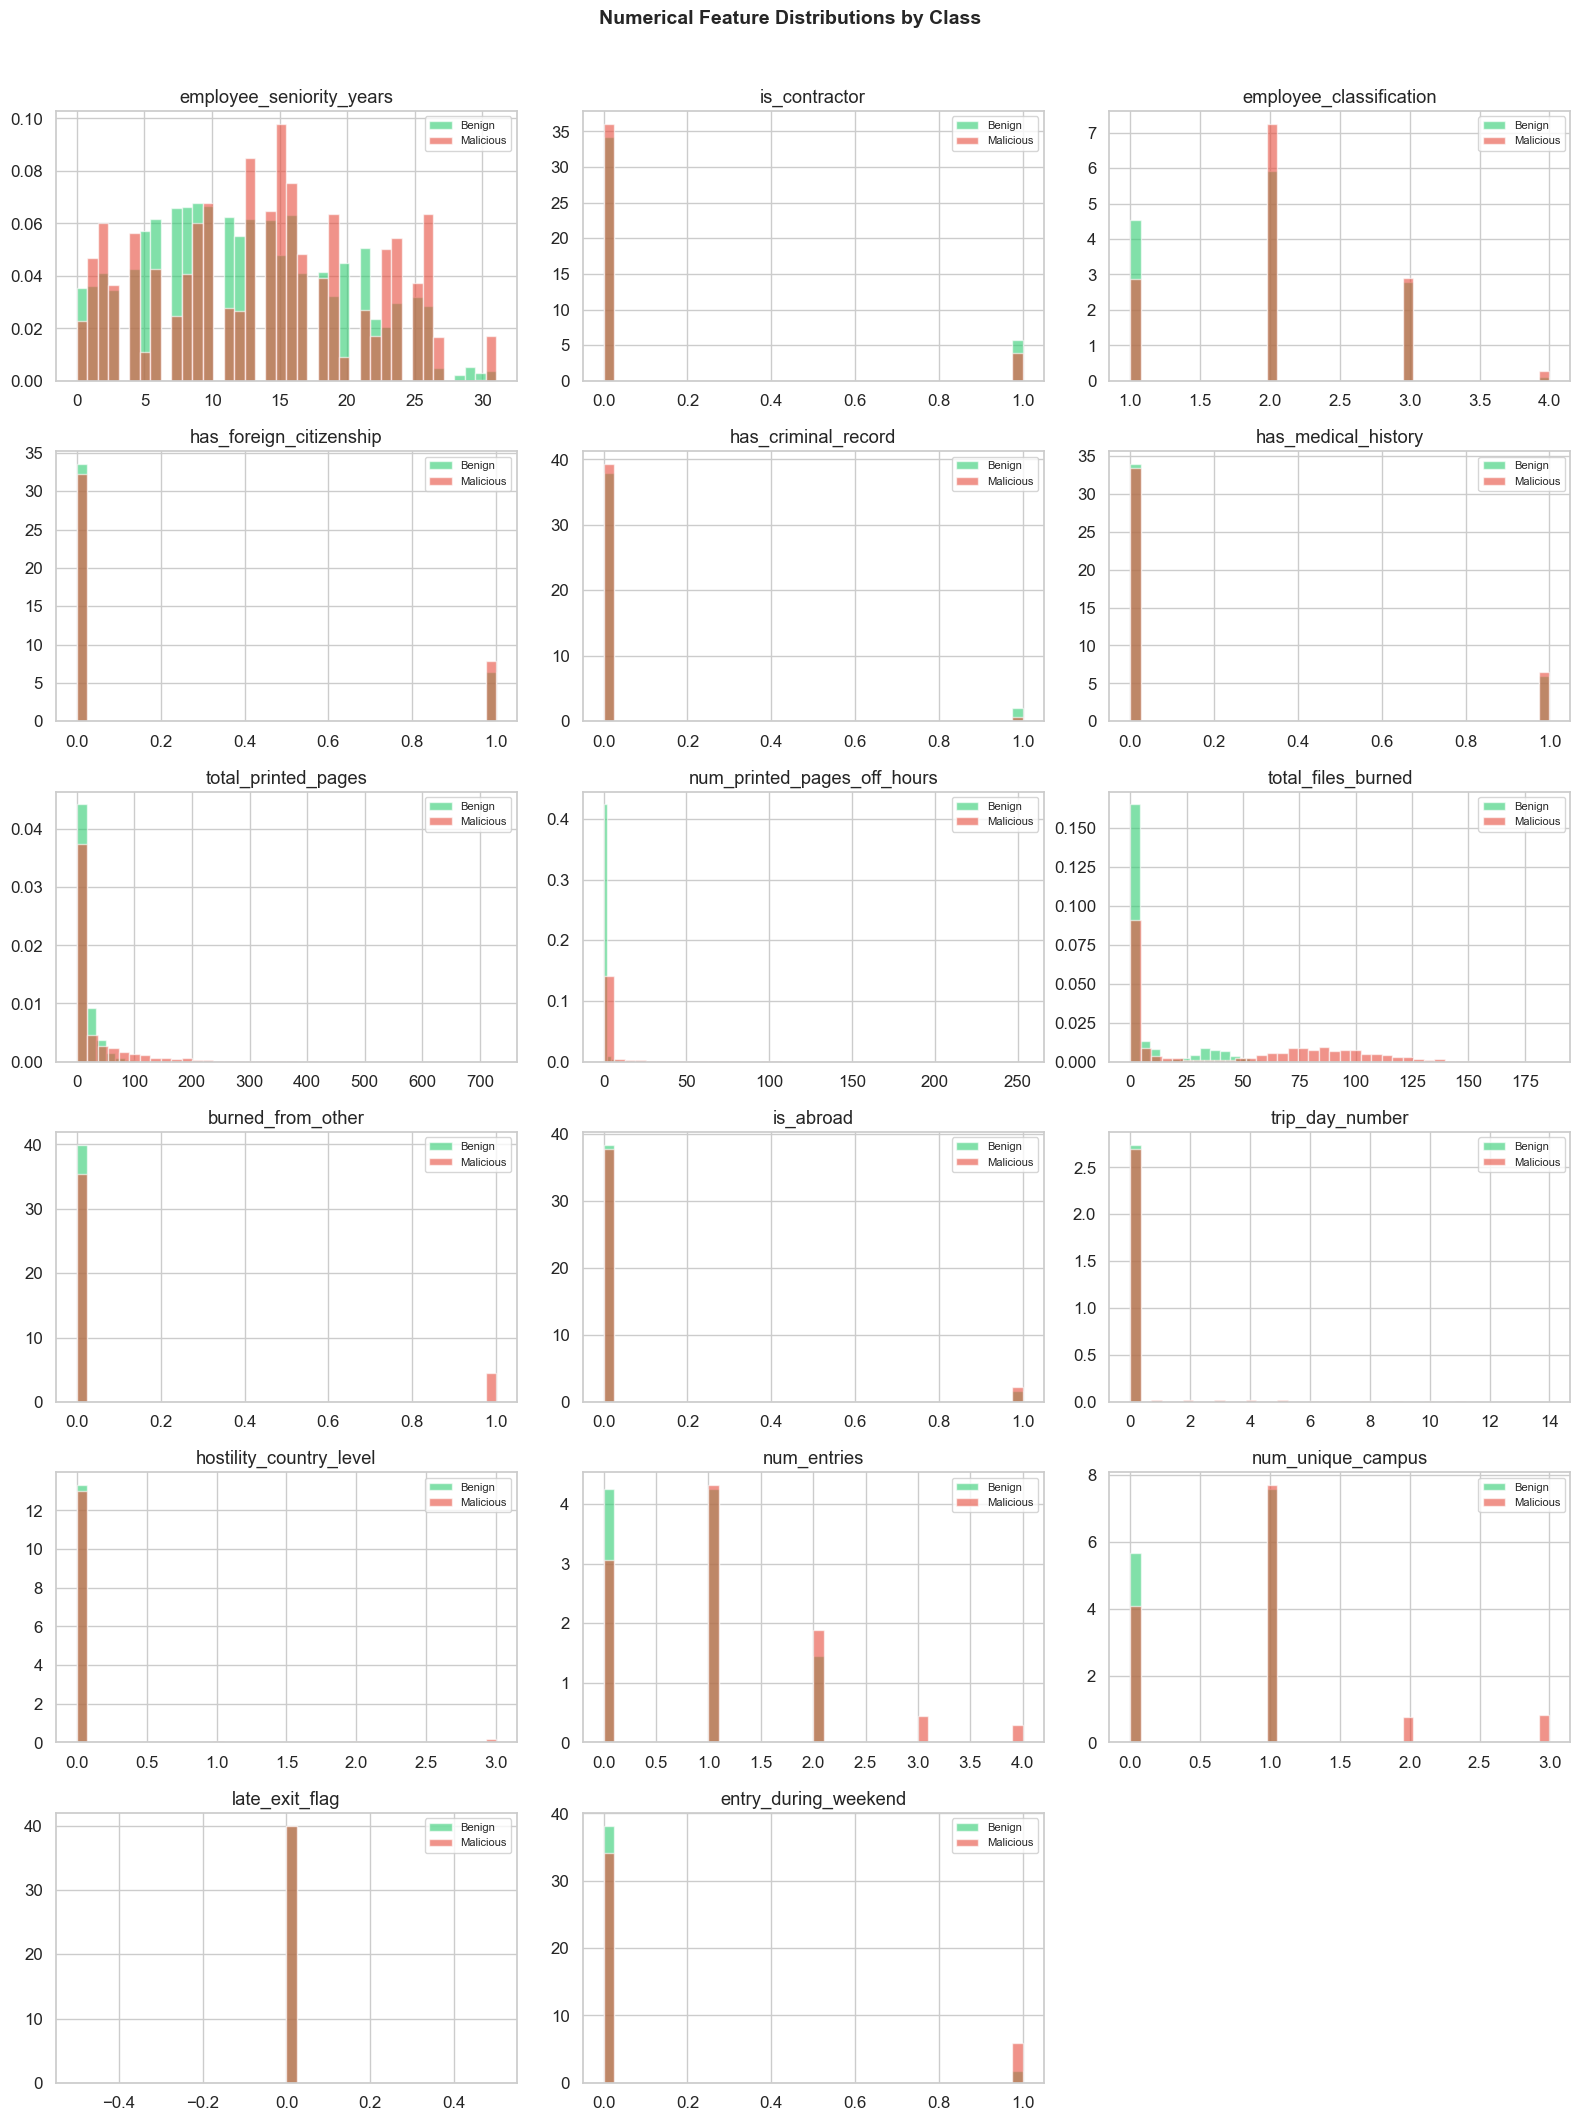

In [6]:
# Distribution plots coloured by class
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color in zip([0, 1], PALETTE):
        data = df[df['is_malicious'] == label][col].dropna()
        axes[i].hist(data, bins=40, alpha=0.6, color=color,
                     label='Benign' if label == 0 else 'Malicious', density=True)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions by Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

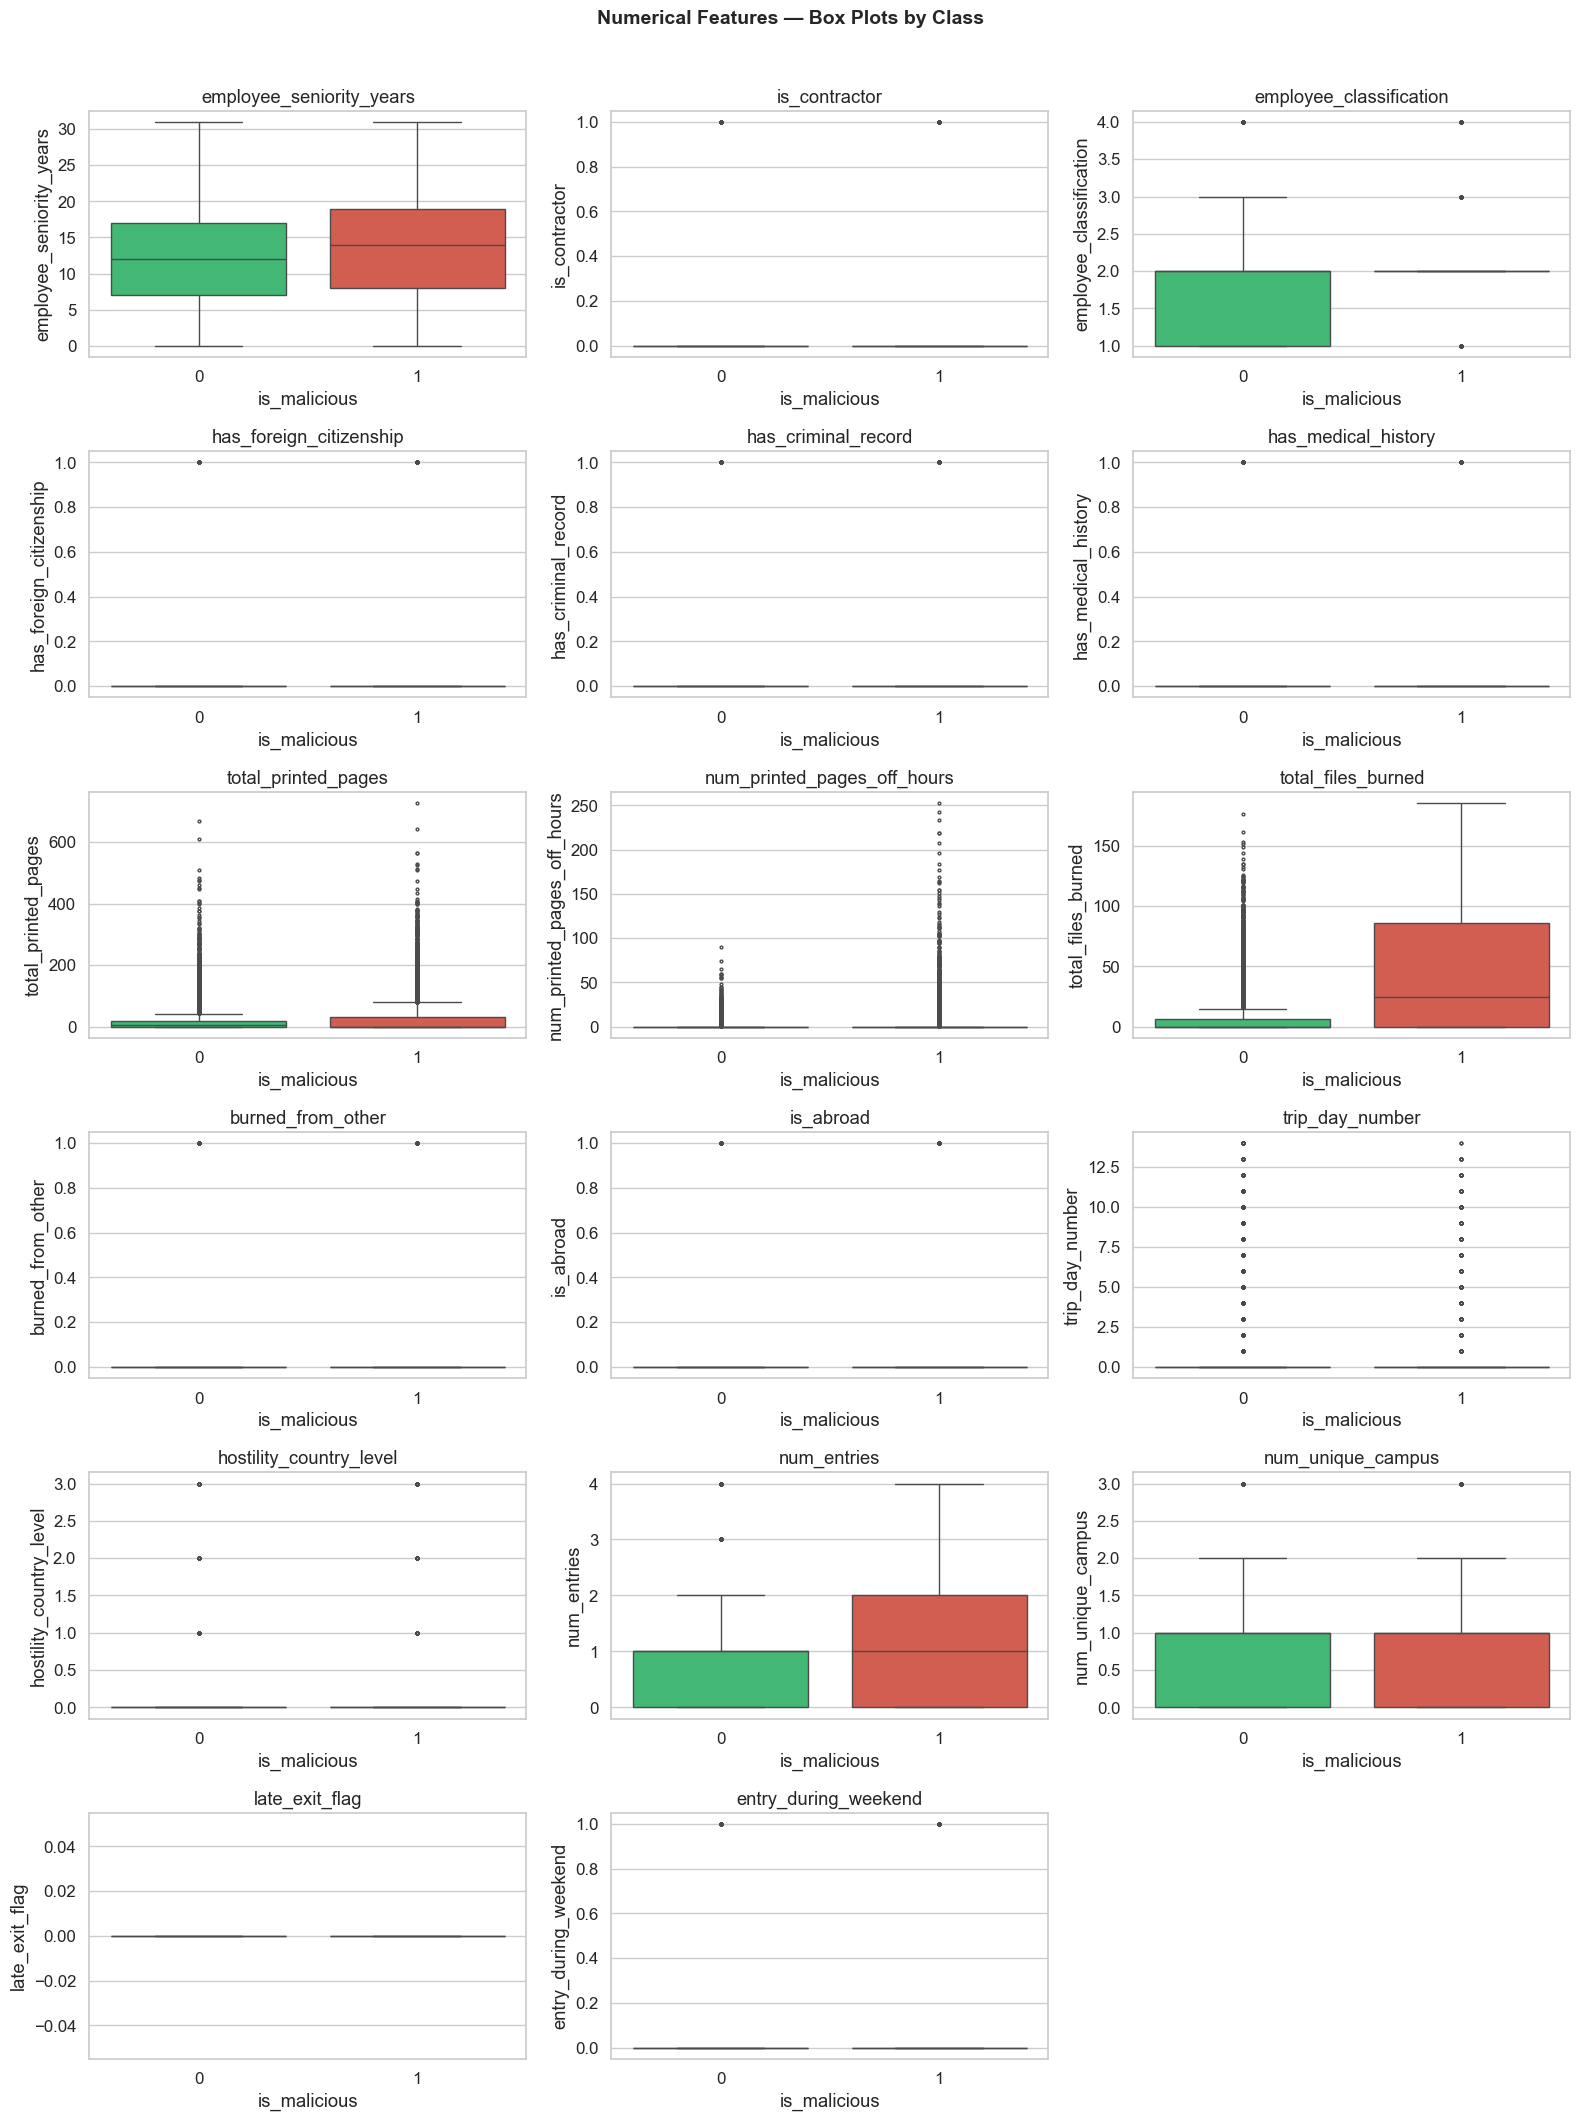

In [7]:
# Box plots — outlier view
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='is_malicious', y=col, palette=PALETTE,
                ax=axes[i], fliersize=2)
    axes[i].set_title(col)
    axes[i].set_xlabel('is_malicious')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features — Box Plots by Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Univariate Analysis — Categorical Features

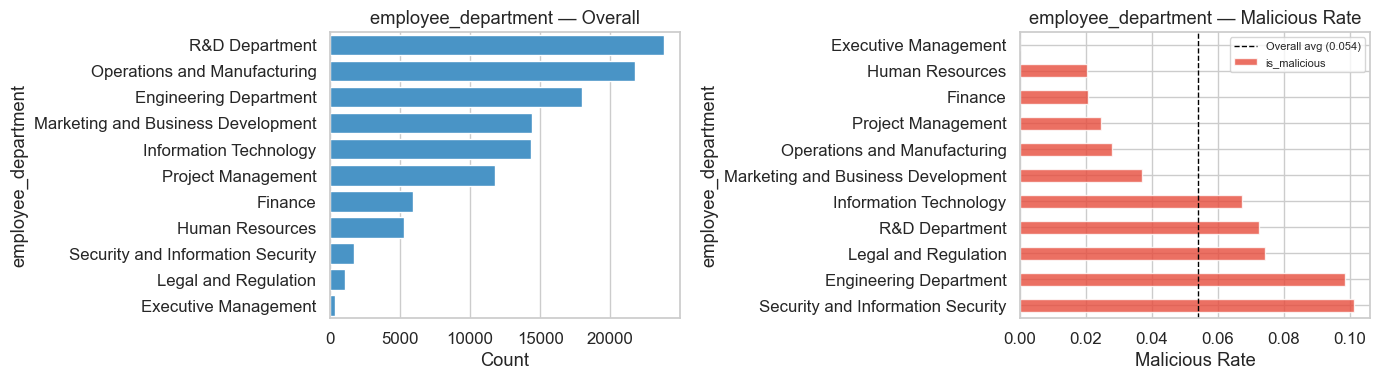

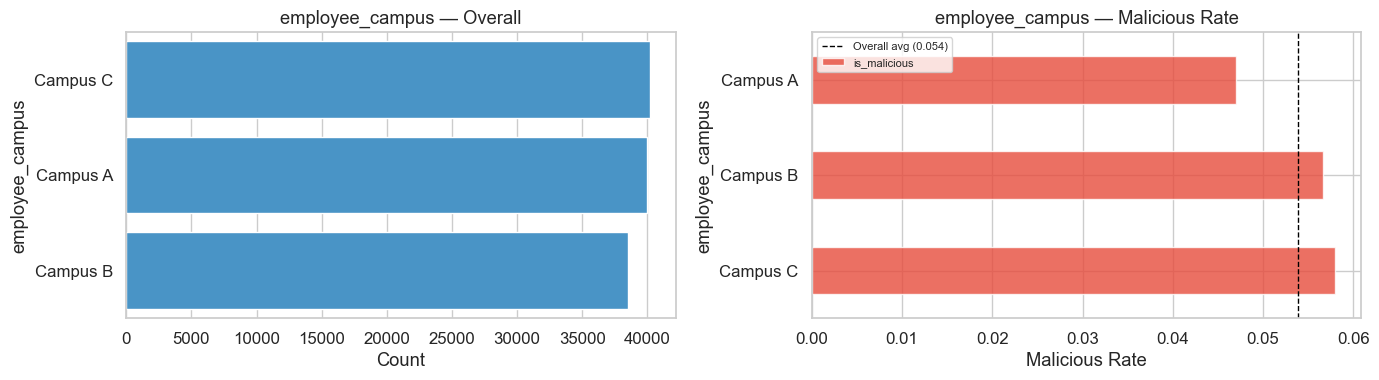

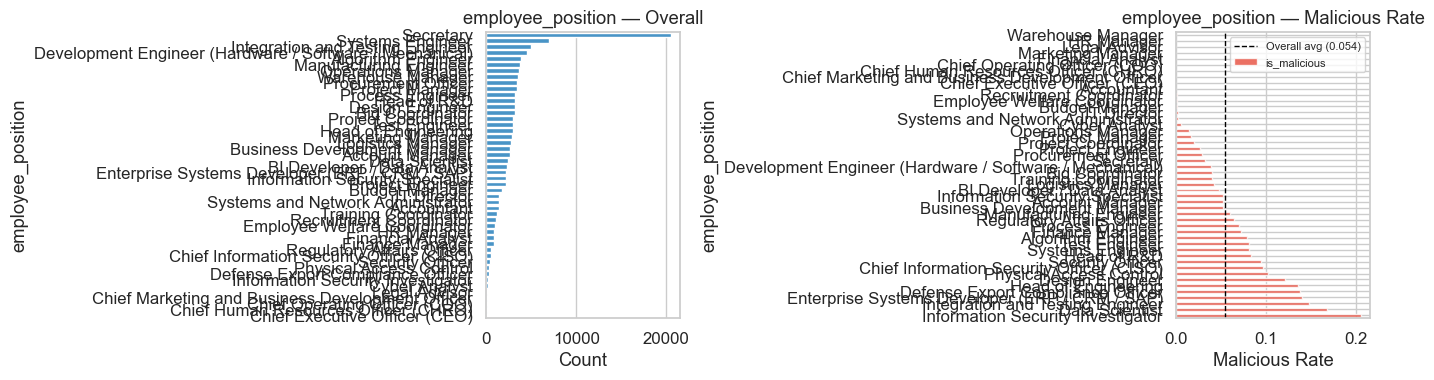

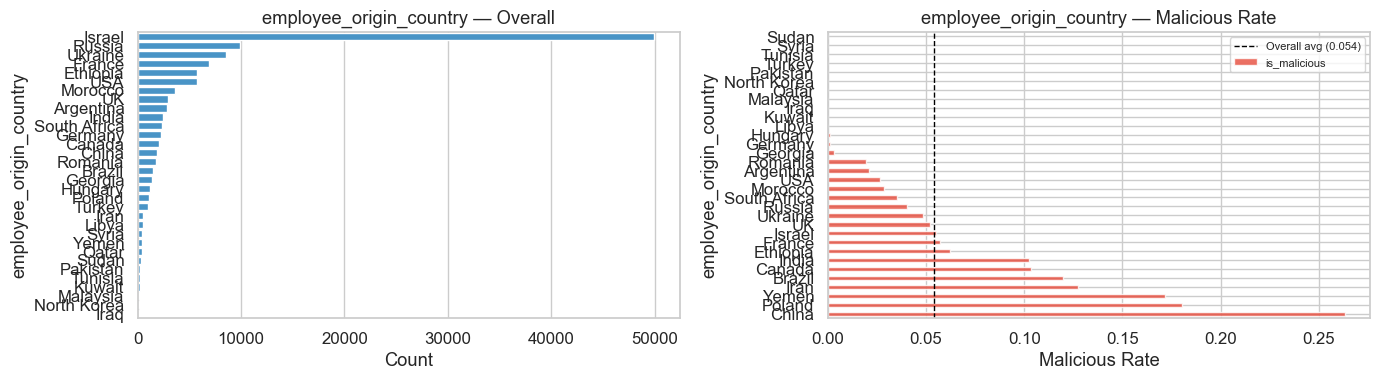

In [8]:
for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Overall distribution
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, color=ACCENT_COLOR, ax=axes[0])
    axes[0].set_title(f'{col} — Overall')
    axes[0].set_xlabel('Count')

    # Malicious rate per category
    mal_rate = df.groupby(col)['is_malicious'].mean().sort_values(ascending=False)
    mal_rate.plot(kind='barh', ax=axes[1], color=MALICIOUS_COLOR, alpha=0.8)
    axes[1].axvline(df['is_malicious'].mean(), color='black', linestyle='--', linewidth=1,
                    label=f'Overall avg ({df["is_malicious"].mean():.3f})')
    axes[1].set_title(f'{col} — Malicious Rate')
    axes[1].set_xlabel('Malicious Rate')
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

---
## 6. Correlation Analysis

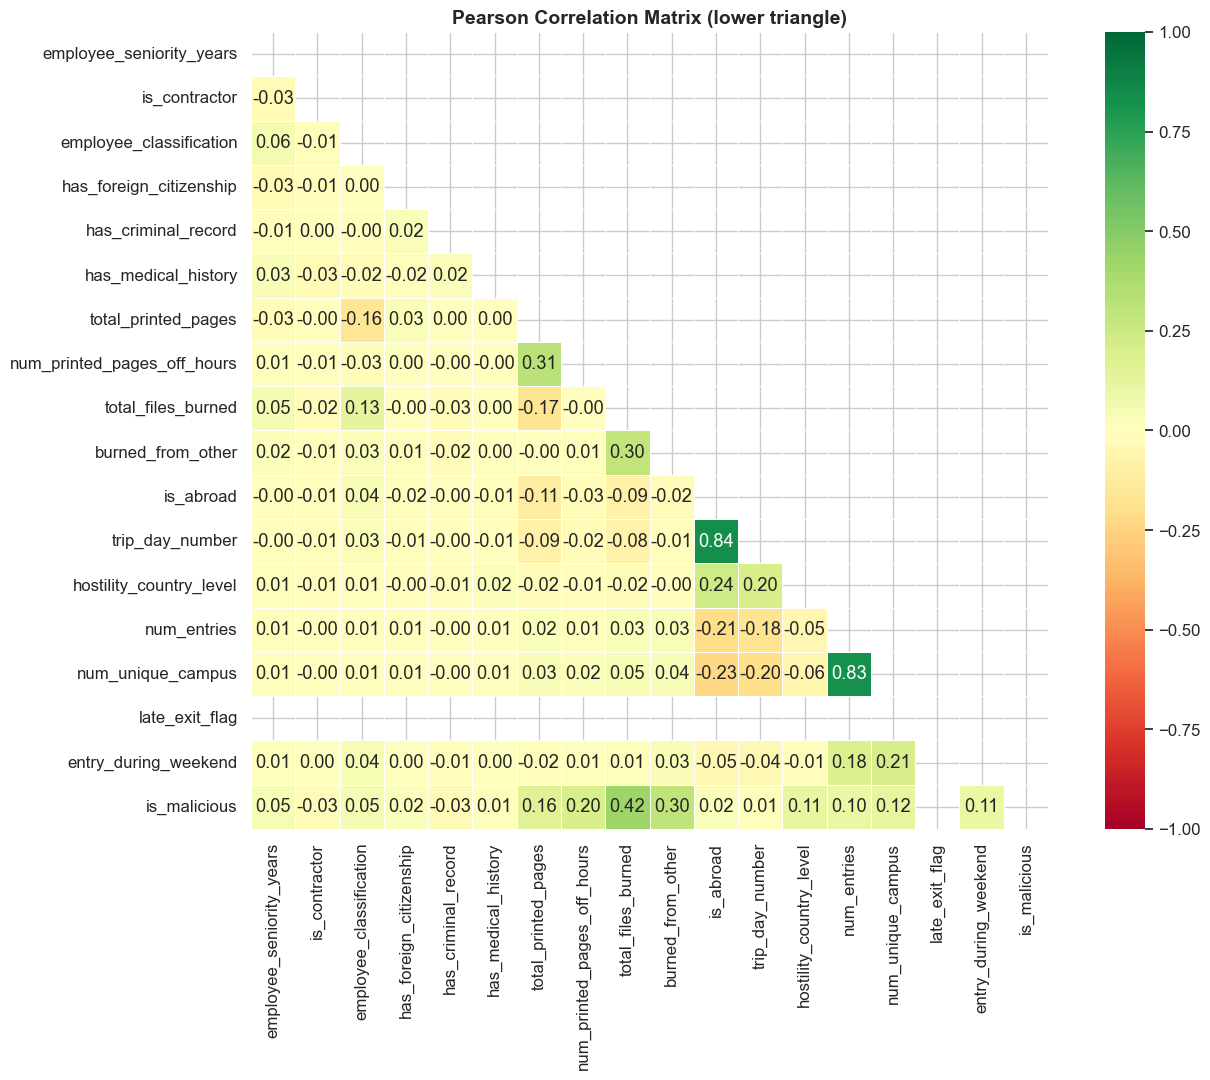

In [9]:
corr_cols = num_cols + ['is_malicious']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, square=True)
ax.set_title('Pearson Correlation Matrix (lower triangle)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

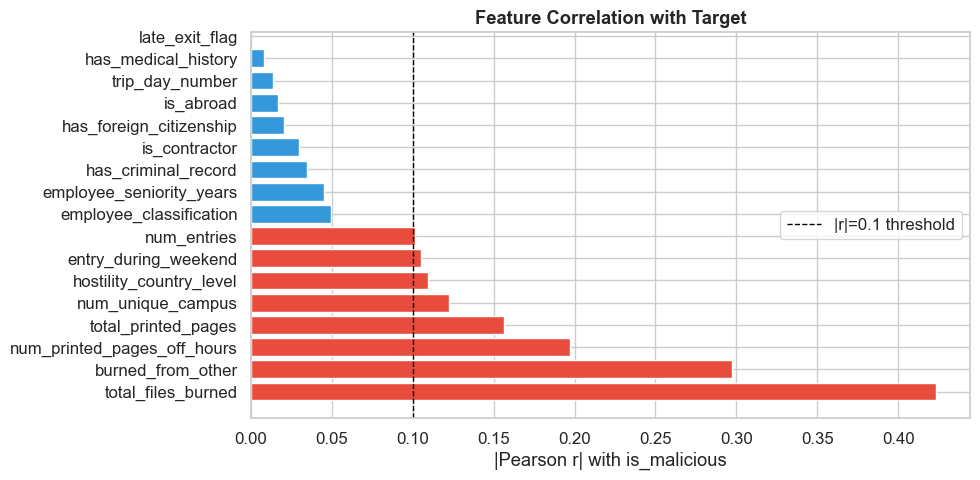


Top 5 correlates with is_malicious:
total_files_burned             0.423465
burned_from_other              0.297451
num_printed_pages_off_hours    0.196895
total_printed_pages            0.156477
num_unique_campus              0.122642
Name: is_malicious, dtype: float64


In [10]:
# Top correlates with target
target_corr = corr_matrix['is_malicious'].drop('is_malicious').abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(target_corr.index, target_corr.values,
               color=[MALICIOUS_COLOR if v > 0.1 else ACCENT_COLOR for v in target_corr.values])
ax.set_xlabel('|Pearson r| with is_malicious')
ax.set_title('Feature Correlation with Target', fontweight='bold')
ax.axvline(0.1, color='black', linestyle='--', linewidth=1, label='|r|=0.1 threshold')
ax.legend()
plt.tight_layout()
plt.show()

print('\nTop 5 correlates with is_malicious:')
print(target_corr.head())

---
## 7. User Behaviour & Anomaly Indicators

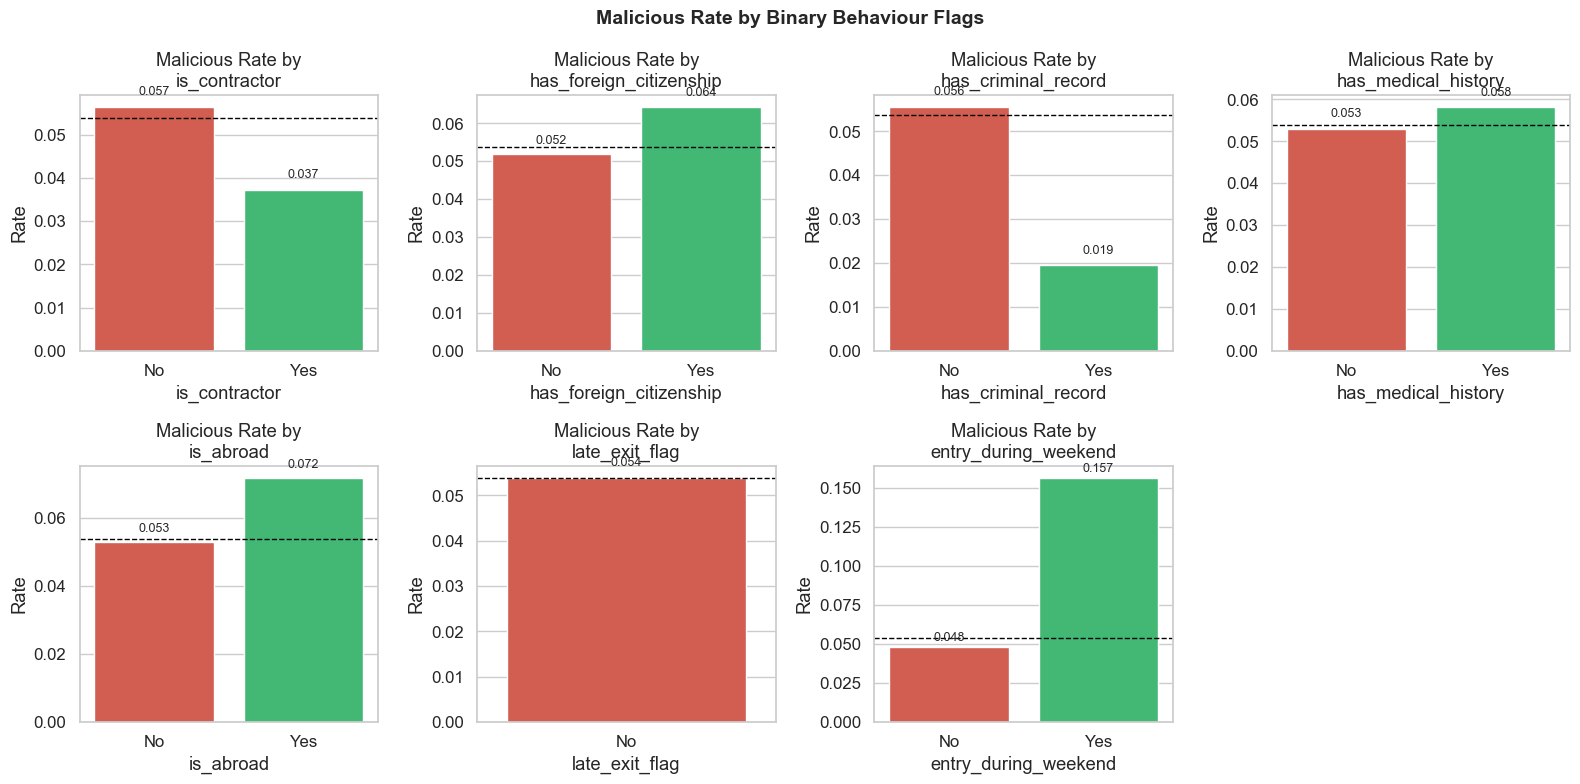

In [11]:
# Binary behaviour flags
behaviour_flags = ['is_contractor', 'has_foreign_citizenship', 'has_criminal_record',
                   'has_medical_history', 'is_abroad', 'late_exit_flag', 'entry_during_weekend']
behaviour_flags = [c for c in behaviour_flags if c in df.columns]

fig, axes = plt.subplots(2, int(np.ceil(len(behaviour_flags)/2)), figsize=(16, 8))
axes = axes.flatten()

for i, flag in enumerate(behaviour_flags):
    ct = df.groupby(flag)['is_malicious'].mean().reset_index()
    ct.columns = [flag, 'malicious_rate']
    ct[flag] = ct[flag].map({0: 'No', 1: 'Yes'})
    sns.barplot(data=ct, x=flag, y='malicious_rate', palette=PALETTE[::-1], ax=axes[i])
    axes[i].set_title(f'Malicious Rate by\n{flag}')
    axes[i].set_ylabel('Rate')
    axes[i].axhline(df['is_malicious'].mean(), color='black', linestyle='--', linewidth=1)
    for bar in axes[i].patches:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                     f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Malicious Rate by Binary Behaviour Flags', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

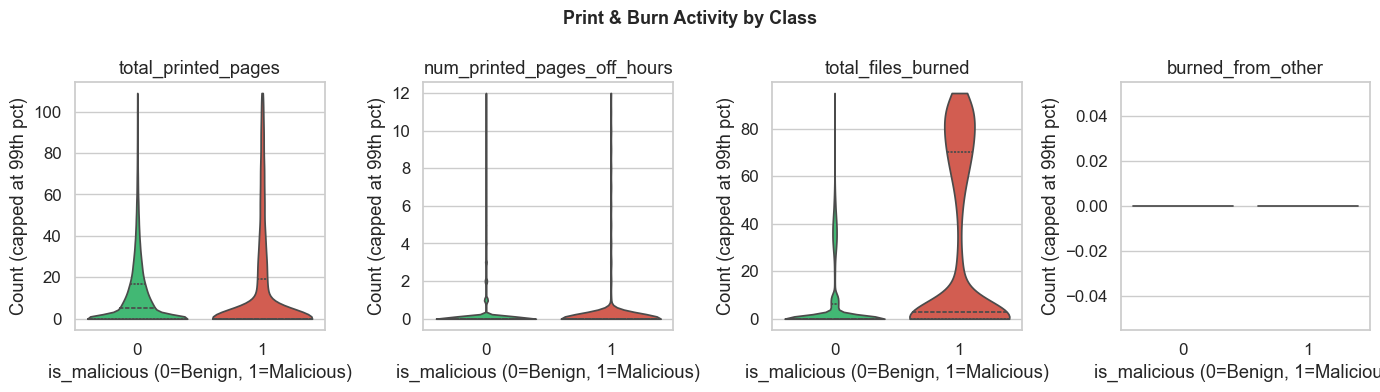

In [12]:
# Printing & burning activity
activity_cols = [c for c in ['total_printed_pages', 'num_printed_pages_off_hours',
                              'total_files_burned', 'burned_from_other'] if c in df.columns]

fig, axes = plt.subplots(1, len(activity_cols), figsize=(14, 4))
if len(activity_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, activity_cols):
    # Cap at 99th percentile for readability
    cap = df[col].quantile(0.99)
    data = df[df[col] <= cap]
    sns.violinplot(data=data, x='is_malicious', y=col, palette=PALETTE,
                   inner='quartile', ax=ax, cut=0)
    ax.set_title(col)
    ax.set_xlabel('is_malicious (0=Benign, 1=Malicious)')
    ax.set_ylabel('Count (capped at 99th pct)')

plt.suptitle('Print & Burn Activity by Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

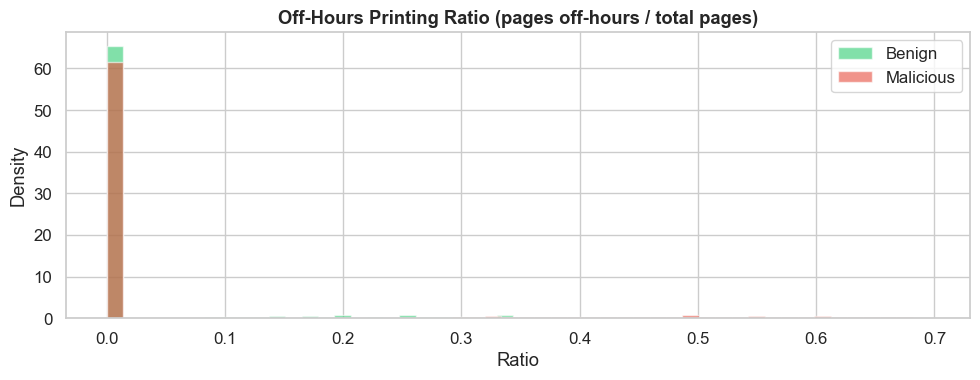

In [13]:
# Off-hours ratio
if 'num_printed_pages_off_hours' in df.columns and 'total_printed_pages' in df.columns:
    df['off_hours_ratio'] = np.where(
        df['total_printed_pages'] > 0,
        df['num_printed_pages_off_hours'] / df['total_printed_pages'],
        0
    )

    fig, ax = plt.subplots(figsize=(10, 4))
    for label, color, name in zip([0, 1], PALETTE, ['Benign', 'Malicious']):
        vals = df[df['is_malicious'] == label]['off_hours_ratio'].dropna()
        ax.hist(vals, bins=50, alpha=0.6, color=color, density=True, label=name)
    ax.set_title('Off-Hours Printing Ratio (pages off-hours / total pages)', fontweight='bold')
    ax.set_xlabel('Ratio')
    ax.set_ylabel('Density')
    ax.legend()
    plt.tight_layout()
    plt.show()

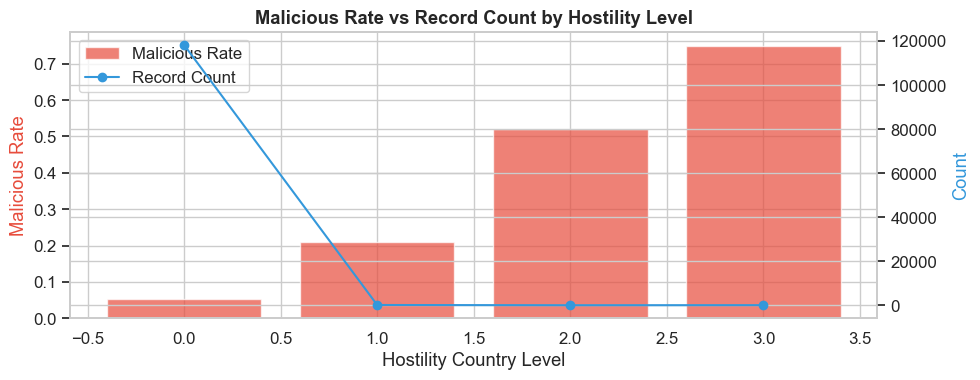

In [14]:
# Hostility country level breakdown
if 'hostility_country_level' in df.columns:
    hcl = df.groupby('hostility_country_level')['is_malicious'].agg(['mean', 'count']).reset_index()
    hcl.columns = ['hostility_level', 'malicious_rate', 'count']

    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax2 = ax1.twinx()
    ax1.bar(hcl['hostility_level'], hcl['malicious_rate'],
            color=MALICIOUS_COLOR, alpha=0.7, label='Malicious Rate')
    ax2.plot(hcl['hostility_level'], hcl['count'],
             color=ACCENT_COLOR, marker='o', label='Record Count')
    ax1.set_xlabel('Hostility Country Level')
    ax1.set_ylabel('Malicious Rate', color=MALICIOUS_COLOR)
    ax2.set_ylabel('Count', color=ACCENT_COLOR)
    ax1.set_title('Malicious Rate vs Record Count by Hostility Level', fontweight='bold')
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2)
    plt.tight_layout()
    plt.show()

---
## 8. Time-Related / Session Analysis

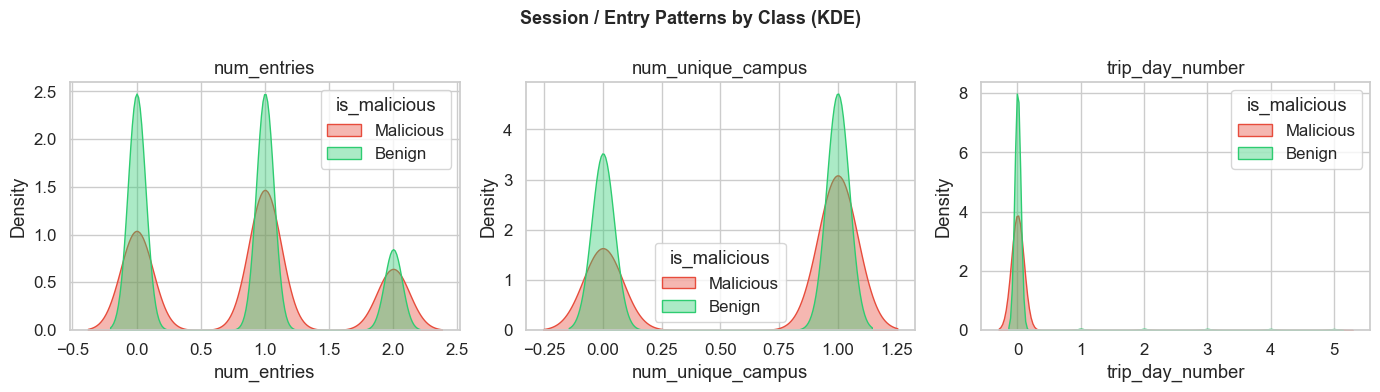

In [15]:
# Entry patterns
entry_cols = [c for c in ['num_entries', 'num_unique_campus', 'trip_day_number'] if c in df.columns]

fig, axes = plt.subplots(1, len(entry_cols), figsize=(14, 4))
if len(entry_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, entry_cols):
    cap = df[col].quantile(0.98)
    data = df[df[col] <= cap]
    sns.kdeplot(data=data, x=col, hue='is_malicious', palette=PALETTE,
                fill=True, alpha=0.4, ax=ax, common_norm=False)
    ax.set_title(col)
    ax.legend(title='is_malicious', labels=['Malicious', 'Benign'])

plt.suptitle('Session / Entry Patterns by Class (KDE)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

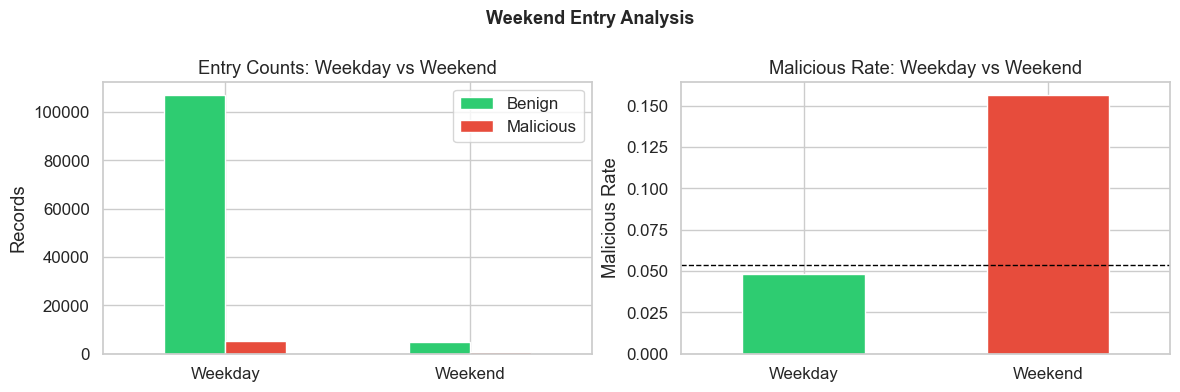

In [16]:
# Weekend vs weekday entries by class
if 'entry_during_weekend' in df.columns:
    wknd = df.groupby(['entry_during_weekend', 'is_malicious']).size().unstack()
    wknd.index = ['Weekday', 'Weekend']
    wknd.columns = ['Benign', 'Malicious']

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    wknd.plot(kind='bar', ax=axes[0], color=PALETTE, edgecolor='white', rot=0)
    axes[0].set_title('Entry Counts: Weekday vs Weekend')
    axes[0].set_ylabel('Records')

    wknd_rate = df.groupby('entry_during_weekend')['is_malicious'].mean()
    wknd_rate.index = ['Weekday', 'Weekend']
    wknd_rate.plot(kind='bar', ax=axes[1], color=[BENIGN_COLOR, MALICIOUS_COLOR], edgecolor='white', rot=0)
    axes[1].set_title('Malicious Rate: Weekday vs Weekend')
    axes[1].set_ylabel('Malicious Rate')
    axes[1].axhline(df['is_malicious'].mean(), color='black', linestyle='--', linewidth=1)

    plt.suptitle('Weekend Entry Analysis', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

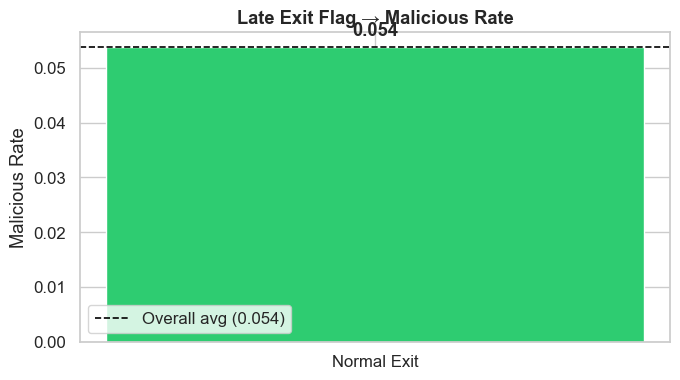

In [17]:
# Late exit analysis
if 'late_exit_flag' in df.columns:
    late = df.groupby('late_exit_flag')['is_malicious'].agg(['mean','count']).reset_index()
    late['late_exit_flag'] = late['late_exit_flag'].map({0: 'Normal Exit', 1: 'Late Exit'})

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(late['late_exit_flag'], late['mean'], color=PALETTE, edgecolor='white', width=0.4)
    ax.axhline(df['is_malicious'].mean(), color='black', linestyle='--',
               linewidth=1.2, label=f'Overall avg ({df["is_malicious"].mean():.3f})')
    ax.set_ylabel('Malicious Rate')
    ax.set_title('Late Exit Flag → Malicious Rate', fontweight='bold')
    ax.legend()
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{bar.get_height():.3f}', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 9. Feature Importance (Random Forest Proxy)

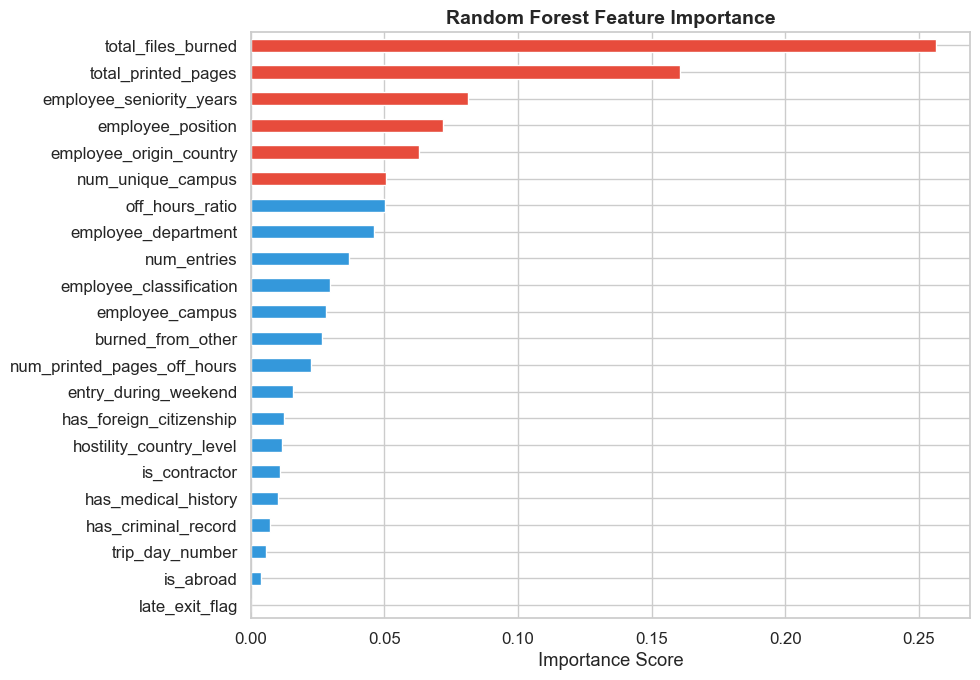


Top 5 Most Important Features:
total_files_burned          0.256553
total_printed_pages         0.160660
employee_seniority_years    0.081291
employee_position           0.071886
employee_origin_country     0.062745
dtype: float64


In [18]:
# Encode categoricals for RF
df_enc = df.copy()
le = LabelEncoder()
for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

feature_cols = [c for c in df_enc.columns if c != 'is_malicious']
X = df_enc[feature_cols].fillna(0)
y = df_enc['is_malicious']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42,
                             class_weight='balanced', n_jobs=-1)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [MALICIOUS_COLOR if v >= importances.quantile(0.75) else ACCENT_COLOR
          for v in importances.values]
importances.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 5 Most Important Features:')
print(importances.sort_values(ascending=False).head())

---
## 10. Summary & Key Findings

In [19]:
top_corr_features = target_corr.head(5).index.tolist()
top_rf_features   = importances.sort_values(ascending=False).head(5).index.tolist()

print('=' * 60)
print('  INSIDER THREAT EDA — KEY FINDINGS')
print('=' * 60)
print(f"\n📦 Dataset      : {df.shape[0]:,} records × {df.shape[1]} features")
print(f"🎯 Target        : is_malicious")
print(f"   Benign        : {(y==0).sum():,} ({(y==0).mean()*100:.1f}%)")
print(f"   Malicious     : {(y==1).sum():,} ({(y==1).mean()*100:.1f}%)")
print(f"   Imbalance     : {(y==0).sum()/(y==1).sum():.1f}:1")
print(f"\n🔗 Top Pearson Correlates with target:")
for f in top_corr_features:
    print(f"   • {f:<35} r = {target_corr[f]:.3f}")
print(f"\n🌲 Top RF Feature Importances:")
for f in top_rf_features:
    imp = importances.sort_values(ascending=False)
    print(f"   • {f:<35} {imp[f]:.4f}")
print()
print('⚠️  Modelling recommendations:')
print('   1. Use stratified splits due to class imbalance (~18:1)')
print('   2. Apply class_weight="balanced" or SMOTE oversampling')
print('   3. Evaluate with F1 / AUC-ROC / Precision-Recall, not accuracy')
print('   4. Investigate top RF features for policy/rule-based flagging')
print('=' * 60)

  INSIDER THREAT EDA — KEY FINDINGS

📦 Dataset      : 118,614 records × 23 features
🎯 Target        : is_malicious
   Benign        : 112,228 (94.6%)
   Malicious     : 6,386 (5.4%)
   Imbalance     : 17.6:1

🔗 Top Pearson Correlates with target:
   • total_files_burned                  r = 0.423
   • burned_from_other                   r = 0.297
   • num_printed_pages_off_hours         r = 0.197
   • total_printed_pages                 r = 0.156
   • num_unique_campus                   r = 0.123

🌲 Top RF Feature Importances:
   • total_files_burned                  0.2566
   • total_printed_pages                 0.1607
   • employee_seniority_years            0.0813
   • employee_position                   0.0719
   • employee_origin_country             0.0627

⚠️  Modelling recommendations:
   1. Use stratified splits due to class imbalance (~18:1)
   2. Apply class_weight="balanced" or SMOTE oversampling
   3. Evaluate with F1 / AUC-ROC / Precision-Recall, not accuracy
   4. Invest